**General Description**

The following notebook contains the code to create, train, validate, and test a rainfall-runoff model using the LSTM-MDN network architecture. The notebook support running experiments in different large-sample hydrology datasets including: CAMELS-GB, CAMELS-US, CAMELS-DE. The details for each dataset can be read from a .yml file.

***Authors:***
- Manuel Alvarez Chaves (manuel.alvarez-chaves@uwaterloo.c)
- Eduardo Acuña Espinoza (eduardo.espinoza@kit.edu)

In [28]:
import datetime
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr

from hy2dl.datasetzoo import get_dataset
from hy2dl.evaluation import calculate_metrics, get_tester
from hy2dl.modelzoo import get_model
from hy2dl.training.basetrainer import BaseTrainer
from hy2dl.utils import get_distribution
from hy2dl.utils.config import Config

base_dir = Path.cwd().resolve()
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

Part 1. Initialize information

In [14]:
# Path to .yml file where the experiment settings are stored.
path_experiment_settings = "../experiments/mdn.yml"

# Read experiment settings
config = Config(path_experiment_settings, base_dir=base_dir)
config.init_experiment()
config.dump()

Dataset = get_dataset(config)
Tester = get_tester(config)

Part 2. Create datasets and dataloaders used to train/validate the model

In [3]:
# Create training dataset
training_dataset = Dataset(cfg=config, time_period="training")
training_dataset.setup_dataset()
# Initialize training object
trainer = BaseTrainer(cfg=config, training_dataset=training_dataset)

2026-03-27 19:17:49 - Creating training dataset in memory...


Processing gauges: 100%|##########| 3/3 [00:04<00:00,  1.61s/entity]


2026-03-27 19:17:57 - Dataset created successfully.
2026-03-27 19:17:57 - Validating samples...


Validating samples: 100%|##########| 88/88 [00:00<00:00, 2578.10tasks/s]

2026-03-27 19:17:57 - Number of gauges with valid samples: 3
2026-03-27 19:17:57 - Number of valid samples: 3 288
2026-03-27 19:17:57 - Mapping ids, dates and features to their corresponding indexes


2026-03-27 19:17:57 - Dataset was successfully standardized.
2026-03-27 19:17:57 - Static attributes were successfully standardized.
2026-03-27 19:17:57 - Time required to process the dataset: 0:00:08
2026-03-27 19:17:59 - ----------------Details training dataloader-----------------
2026-03-27 19:17:59 - Batch structure (number of batches: 12)
2026-03-27 19:17:59 -              Key              |            Shape             
2026-03-27 19:18:12 - x_d
2026-03-27 19:18:12 -      prcp(mm/day)_daymet      |    torch.Size([256, 365])    
2026-03-27 19:18:12 -       PRCP(mm/day)_nldas      |    torch.Size([256, 365])    
2026-03-27 19:18:12 -      PRCP(mm/day)_maurer      |    torch.Size([256, 365])    
2026-03-27 19:18:12 -       srad(W/m2)_daymet       |    torch.Size([256, 365])    
2026-03-27 19:18:12 -         tmax(C)_daymet        |    torch.Size([256, 365])    
2026-03-27 19:18:12 -         tmin(C)_daymet        |    torch.Size([256, 365])    
2026-03-27 19:18:12 -         vp(Pa)_day

c:\Users\acuna\KIT\Hy2DL\.venv\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [4]:
validation_dataset = Dataset(cfg=config, time_period="validation")
validation_dataset.setup_dataset(check_nan=False, path_scaler = config.path_save_folder / "scaler.yml" )
tester_validation = Tester(cfg=config, evaluation_dataset=validation_dataset)

2026-03-27 19:18:46 - Creating validation dataset in memory...


Processing gauges: 100%|##########| 3/3 [00:02<00:00,  1.04entity/s]


2026-03-27 19:18:51 - Dataset created successfully.
2026-03-27 19:18:51 - Validating samples...


Validating samples: 100%|##########| 25/25 [00:00<00:00, 4701.29tasks/s]

2026-03-27 19:18:51 - Number of gauges with valid samples: 3
2026-03-27 19:18:51 - Number of valid samples: 3 285
2026-03-27 19:18:51 - Mapping ids, dates and features to their corresponding indexes
2026-03-27 19:18:51 - Dataset was successfully standardized.
2026-03-27 19:18:51 - Static attributes were successfully standardized.
2026-03-27 19:18:51 - Time required to process the dataset: 0:00:05


Part 3. Train model

In [5]:
# Training report structure
validation_headers = "".join([f"{m:^10}|" for m in config.validation_metric])
config.logger.info("Training model".center(60, "-"))
config.logger.info(f"{'':^16}|{'Training':^21}|{'Validation':^{(11 * len(config.validation_metric)) + 10}}|")
config.logger.info(f"{'Epoch':^5}|{'LR':^10}|{'Loss':^10}|{'Time':^10}|{validation_headers}{'Time':^10}|")

# Loop through epochs
total_time = time.time()
for epoch in range(1, config.epochs + 1):
    trainer.train_model(epoch=epoch)  # Training
    tester_validation.validate_model(model=trainer.model, epoch=epoch)  # Validation
    config.logger.info(trainer.report + tester_validation.validation_report)  # report

config.logger.info(f"Total training time: {datetime.timedelta(seconds=int(time.time() - total_time))}\n")
shutil.rmtree(tester_validation.path_zarr, ignore_errors=True)  # delete validation results

2026-03-27 19:18:53 - -----------------------Training model-----------------------
2026-03-27 19:18:53 -                 |      Training       |           Validation           |
2026-03-27 19:18:53 - Epoch|    LR    |   Loss   |   Time   |   nse    |   nll    |   Time   |


2026-03-27 19:19:30 -   1  | 0.00050  |  0.893   | 0:00:20  |  0.254   |  2.207   | 0:00:16  |
2026-03-27 19:19:30 - Total training time: 0:00:37



Part 4. Test model

In [ ]:
# If I already trained a model, I can re-construct it using the saved parameters from a given epoch
#model = get_model(config).to(config.device)
#model.load_state_dict(torch.load(config.path_save_folder / "model" / f"model_epoch_{config.epochs}", map_location=config.device))

In [7]:
testing_dataset = Dataset(cfg=config, time_period="testing")
testing_dataset.setup_dataset(check_nan=False, path_scaler = config.path_save_folder / "scaler.yml" )
tester_testing = Tester(cfg=config, evaluation_dataset=testing_dataset)

config.logger.info("Testing model...")
testing_time = time.time()
tester_testing.evaluate_model(model = trainer.model)
config.logger.info("Testing completed.")
config.logger.info(f"Total testing time: {datetime.timedelta(seconds=int(time.time() - testing_time))}\n")

2026-03-27 19:20:07 - Creating testing dataset in memory...


Processing gauges: 100%|##########| 3/3 [00:05<00:00,  1.87s/entity]


2026-03-27 19:20:16 - Dataset created successfully.
2026-03-27 19:20:16 - Validating samples...


Validating samples: 100%|##########| 25/25 [00:00<00:00, 4589.15tasks/s]

2026-03-27 19:20:16 - Number of gauges with valid samples: 3
2026-03-27 19:20:16 - Number of valid samples: 11 046
2026-03-27 19:20:16 - Mapping ids, dates and features to their corresponding indexes
2026-03-27 19:20:16 - Dataset was successfully standardized.
2026-03-27 19:20:16 - Static attributes were successfully standardized.
2026-03-27 19:20:16 - Time required to process the dataset: 0:00:08
2026-03-27 19:20:16 - Testing model...


2026-03-27 19:20:39 - Testing completed.
2026-03-27 19:20:39 - Total testing time: 0:00:23



Part 5. Initial analysis

In [ ]:
test_results = xr.open_zarr(tester_testing.path_zarr)
testing_metrics = calculate_metrics(ds_results=test_results, metric_name = config.testing_metrics, distribution= config.distribution)
testing_metrics.to_zarr(config.path_save_folder / "testing_metrics.zarr", mode="w")

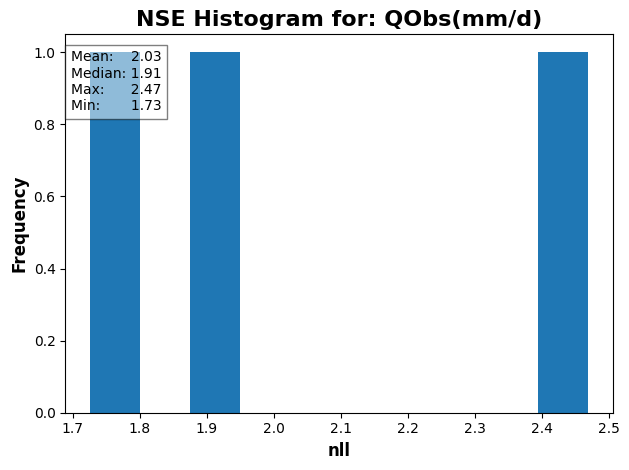

In [21]:
# Loss testing
target_of_interest = random.sample(list(testing_metrics.feature.values), 1)[0]
metric_of_interest = random.sample(list(testing_metrics.metric.values), 1)[0]
test_metric = testing_metrics.sel(feature=target_of_interest, metric=metric_of_interest).values
# Plot the histogram
plt.hist(test_metric)

# Add NSE statistics to the plot
plt.text(
    0.01,
    0.8,
    (
        f"Mean: {'%.2f' % np.mean(test_metric):>7}\n"
        f"Median: {'%.2f' % np.median(test_metric):>0}\n"
        f"Max: {'%.2f' % np.max(test_metric):>9}\n"
        f"Min: {'%.2f' % np.min(test_metric):>10}"
    ),
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", alpha=0.5),
)

# Format plot
plt.rcParams["figure.figsize"] = (10, 5)
plt.xlabel(metric_of_interest, fontsize=12, fontweight="bold")
plt.ylabel("Frequency", fontsize=12, fontweight="bold")
plt.title(f"NSE Histogram for: {target_of_interest}", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

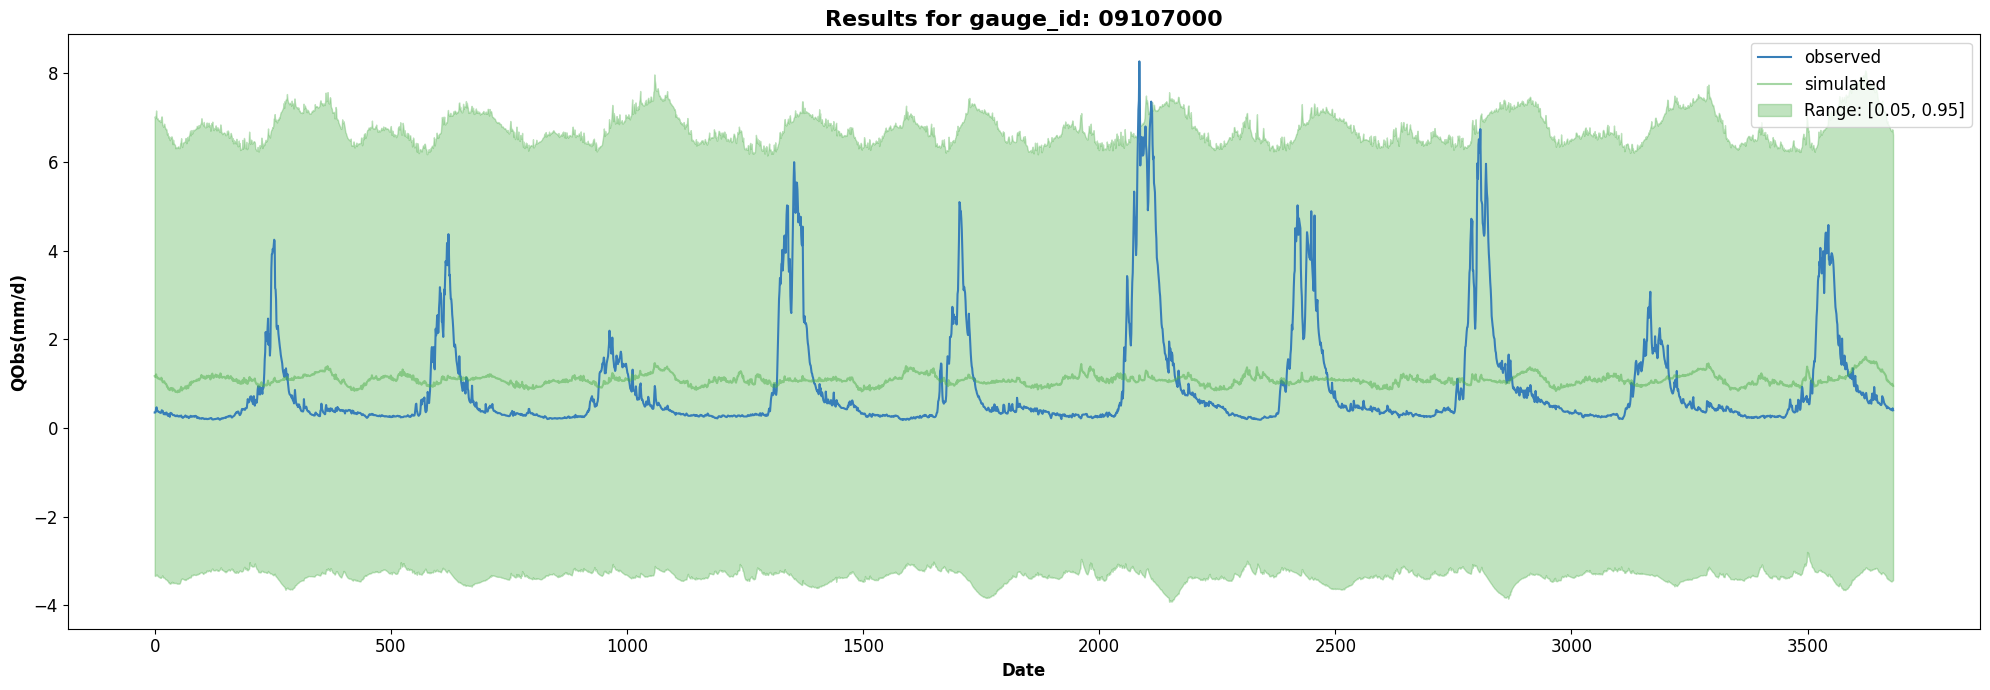

In [91]:
# Plot simulated and observed discharges
basin_to_analyze = random.sample(list(test_results.gauge_id.values), 1)[0]
y_sim = test_results.sel(gauge_id=basin_to_analyze, feature=target_of_interest)["y_sim"].compute().values
y_obs = test_results.sel(gauge_id=basin_to_analyze, feature=target_of_interest)["y_obs"].compute().values

# Calculate quantiles
quantiles = [0.05, 0.95]
distribution = get_distribution(config.distribution)
params = (
    test_results[list(distribution.parameters)]
    .sel(gauge_id=basin_to_analyze, feature=target_of_interest)
    .drop_vars(["gauge_id", "feature"])
)
params = {
    var: torch.tensor(params[var].values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1) for var in params.data_vars
}
weights = (
    torch.tensor(
        test_results["mdn_weight"].sel(gauge_id=basin_to_analyze, feature=target_of_interest).values,
        dtype=torch.float32,
    )
    .unsqueeze(0)
    .unsqueeze(-1)
)
quantile = distribution.quantile(params=params, weights=weights, q=quantiles).squeeze(0)

plt.figure(figsize=(20, 7))
plt.plot(y_obs, label="observed", color=color_palette["observed"])
plt.plot(y_sim, label="simulated", alpha=0.5, color=color_palette["simulated"])
plt.fill_between(
    range(quantile.shape[0]),
    quantile[:, 0, 0].numpy(),
    quantile[:, 1, 0].numpy(),
    color=color_palette["simulated"],
    alpha=0.35,
    label=f"Range: [{quantiles[0]}, {quantiles[-1]}]",
)


# Format plot
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel(target_of_interest, fontsize=12, fontweight="bold")
plt.title(f"Results for gauge_id: {basin_to_analyze}", fontsize=16, fontweight="bold")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend(loc="upper right", fontsize=12)
plt.tight_layout()
plt.show()

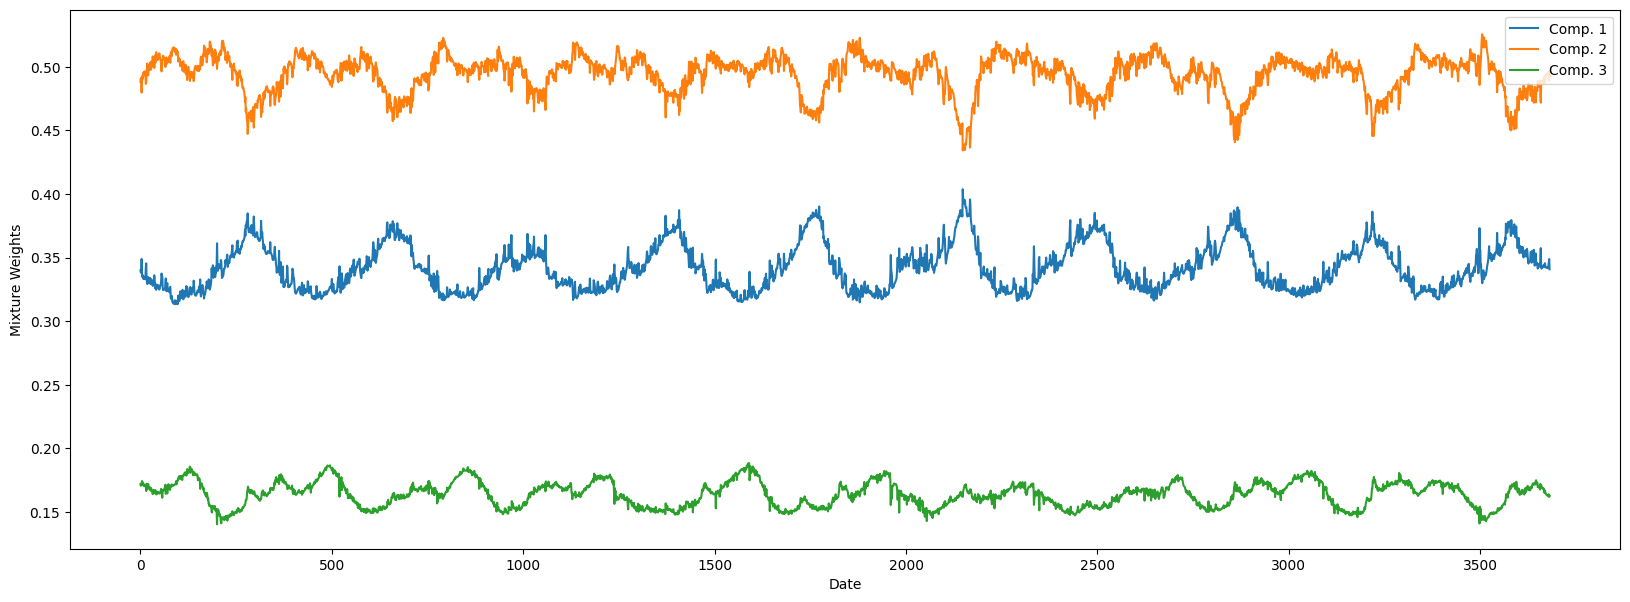

In [97]:
mdn_weights = (
    test_results["mdn_weight"]
    .sel(gauge_id=basin_to_analyze, feature=target_of_interest)
    .drop_vars(["gauge_id", "feature"])
    .values
)

plt.figure(figsize=(20, 7))
for i in range(mdn_weights.shape[1]):
    plt.plot(mdn_weights[:, i], label=f"Comp. {i + 1}")


plt.ylabel("Mixture Weights")
plt.xlabel("Date")
plt.legend()
plt.show()